# Shared (SEF) daily-rainfall animation

This notebook animates the daily rainfall **exactly as it is shared with others**
-- it reads only the exported [Station Exchange Format](https://datarescue.climate.copernicus.eu/station-exchange-format-sef)
(SEF) `.tsv` files produced by [export_sef.ipynb](export_sef.ipynb), and nothing
from the working databases.

It is the SEF counterpart of [generate_rainfall_animation.ipynb](generate_rainfall_animation.ipynb):
same tall UK framing, square-root colour scale, coastlines and interpolated
between-day smoothing. Two things differ:

- **Values are in millimetres** (SEF stores mm), so the colour scale runs higher.
- **QC is made visible.** Every SEF observation carries its verdicts
  (`qc1` from the exact-monthly check, `qc2` from the secondary XGBoost check).
  A station whose observation **passed either** check is drawn with its value; a
  station that **failed both** is drawn instead as a red error cross and its
  value is excluded from the rainfall field.

## How the pipeline works

The animation is produced by four local stages, mirroring the ensemble
animation:

| Stage | Script | Local runner | Purpose |
|-------|--------|--------------|---------|
| precompute | `scripts/render_sef_animation_manifest.py` | `scripts/slurm/submit_sef_animation.sh` | write `manifest.json` (frame plan + SEF root) |
| render | `scripts/render_sef_animation_shard.py` | `scripts/slurm/submit_sef_animation.sh` | render each shard's frames from SEF files |
| validate | `scripts/render_animation_validate.py` | `scripts/slurm/submit_sef_animation.sh` | confirm every frame exists |
| encode | `scripts/render_animation_encode.py` | `scripts/slurm/submit_sef_animation.sh` | `ffmpeg` frames into an H.264 MP4 |

Frame indexing, interpolation density and shard maths are shared with the
daily-rainfall animation, so a SEF frame lines up with the same calendar day.
Each render shard reads a whole SEF year once, then renders all its frames.

Everything is stored under `$PDIR/sef_animation/` and configured in
`scripts/slurm/config.sh` via `SEFANIM_*` variables (overridable at run time).
The prerequisite is the SEF export itself (`scripts/slurm/submit_sef_export.sh`).

## Setup

In [10]:
import os
import subprocess
from datetime import date, timedelta
from pathlib import Path

import src.rainfall_rescue_sqlite as _pkg
from src.rainfall_rescue_sqlite.sef_animation import (
    load_year,
    render_frame_range,
    frame_filename,
    total_frames,
)

repo_root = Path(_pkg.__file__).resolve().parents[2]
slurm_submit_script = repo_root / "scripts" / "slurm" / "submit_sef_animation.sh"

os.environ.setdefault("PDIR", "/data/scratch/philip.brohan/ADRQ")
pdir = Path(os.environ["PDIR"])
sefanim_dir = pdir / "sef_animation"
sef_root = pdir / "sef_export"

print(f"repo_root:       {repo_root}")
print(f"slurm submit:    {slurm_submit_script}")
print(f"SEF export root: {sef_root}")
print(f"animation dir:   {sefanim_dir}")

repo_root:       /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-QC-MO
slurm submit:    /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-QC-MO/scripts/slurm/submit_sef_animation.sh
SEF export root: /data/scratch/philip.brohan/ADRQ/sef_export
animation dir:   /data/scratch/philip.brohan/ADRQ/sef_animation


## Render a few frames locally

Before launching a full-year run, render a handful of frames here to check the
SEF reader and the good/error styling. If the operational SEF export does not
exist yet, a small demo export of the first ~1500 `file_id`s is written to
`/var/tmp` so the notebook is self-contained.

In [3]:
# Use the real SEF export if present, otherwise build a small demo one.
demo_sef_root = sef_root
if not (demo_sef_root / "tsv").is_dir():
    from src.rainfall_rescue_sqlite.sef_export import export_sef

    demo_sef_root = Path("/var/tmp/sef_demo")
    os.environ.setdefault("DUCKDB_MEMORY_LIMIT", "3GB")
    os.environ.setdefault("DUCKDB_TEMP_DIR", "/var/tmp/duckdb_sef_anim")
    Path(os.environ["DUCKDB_TEMP_DIR"]).mkdir(parents=True, exist_ok=True)
    print(f"No operational SEF export found; writing a demo export to {demo_sef_root} ...")
    export_sef(output_root=demo_sef_root, start_file_id=1, end_file_id=1500)

# Pick the year with the most SEF files to animate.
year_dirs = sorted((demo_sef_root / "tsv").glob("*"))
demo_year = max(
    (int(d.name) for d in year_dirs if d.is_dir() and d.name.isdigit()),
    key=lambda y: len(list((demo_sef_root / "tsv" / str(y)).glob("*.tsv"))),
)
print(f"SEF root:  {demo_sef_root}")
print(f"demo year: {demo_year} ({len(list((demo_sef_root / 'tsv' / str(demo_year)).glob('*.tsv')))} station files)")

SEF root:  /data/scratch/philip.brohan/ADRQ/sef_export
demo year: 1939 (3701 station files)


In [4]:
# Load the demo year and centre the clip on its busiest day.
year_data = load_year(demo_sef_root, demo_year)
busiest = max(year_data.by_day, key=lambda md: len(year_data.by_day[md]))
start_date = date(demo_year, busiest[0], busiest[1])
end_date = min(start_date + timedelta(days=2), date(demo_year, 12, 31))
frames_per_day = 3

frame_dir = Path("/var/tmp/sef_anim_demo")
frame_dir.mkdir(parents=True, exist_ok=True)
n_frames = total_frames(start_date, end_date, frames_per_day)

written = render_frame_range(
    sef_root=demo_sef_root,
    start_date=start_date,
    end_date=end_date,
    frames_per_day=frames_per_day,
    first_index=0,
    last_index=n_frames - 1,
    output_dir=frame_dir,
)
print(f"Rendered {len(written)} frames for {start_date} -> {end_date} into {frame_dir}")

Rendered 7 frames for 1939-01-01 -> 1939-01-03 into /var/tmp/sef_anim_demo


1939-01-01:  3609 stations passed QC, 92 failed both (red crosses)


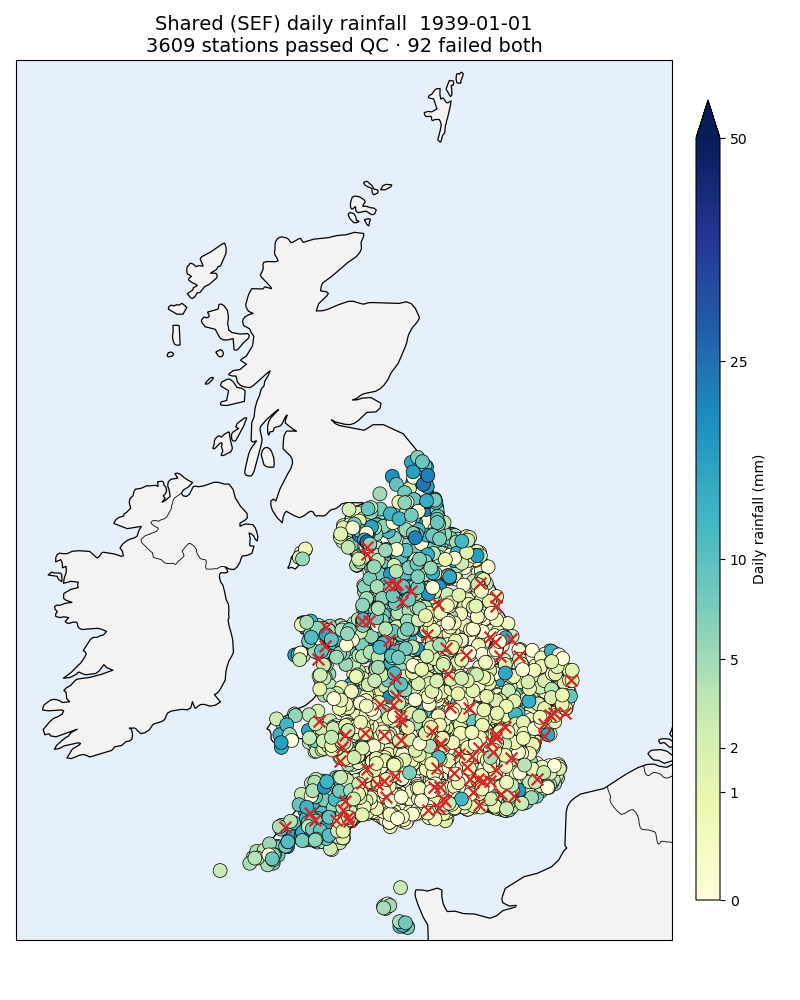

In [5]:
# Report the good/error split on the centre day and show that frame.
from IPython.display import Image, display

day_values = year_data.day_values(start_date)
n_error = sum(1 for s in day_values.values() if s.is_error)
n_good = len(day_values) - n_error
print(f"{start_date}:  {n_good} stations passed QC, {n_error} failed both (red crosses)")

display(Image(filename=str(frame_dir / frame_filename(0))))

## Submit a test run (a single year)

Once local sample frames look right, render a full year with the local staged
pipeline. The environment variables below override `SEFANIM_*` defaults in
`config.sh` for this run only. The cell prints stage output.

In [ ]:
# Submit a small test year via the SLURM submitter and stream the output so it does
# not look like a dead process while the cluster jobs are queued.
print(f"Launching SLURM SEF-animation pipeline from {repo_root}")
print(f"  dates: {test_env['SEFANIM_DATE_START']} -> {test_env['SEFANIM_DATE_END']}")
print(f"  shards: {test_env['SEFANIM_NUM_SHARDS']}")

proc = subprocess.Popen(
    ["bash", str(slurm_submit_script)],
    env=test_env,
    cwd=str(repo_root),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

for line in proc.stdout:
    print(line, end="", flush=True)

rc = proc.wait()
if rc != 0:
    raise SystemExit(f"SLURM sef_animation pipeline failed with code {rc}")
print("SLURM sef_animation pipeline submitted successfully")

Launching local Sef-animation pipeline from /home/users/philip.brohan/Projects/Auto-Daily-Rainfall-QC-MO
  dates: 1931-01-01 -> 1931-12-31
  shards: 50
>>> [sef_animation] single stage: sef_render_precompute.sbatch
Building SEF-animation manifest -> /data/scratch/philip.brohan/ADRQ/sef_animation/manifest.json
Wrote SEF-animation manifest: /data/scratch/philip.brohan/ADRQ/sef_animation/manifest.json
  1093 frames across 50 shards (1931-01-01 -> 1931-12-31, 3/day)
  sef root:  /data/scratch/philip.brohan/ADRQ/sef_export
  frame dir: /data/scratch/philip.brohan/ADRQ/sef_animation/frames
  output:    /data/scratch/philip.brohan/ADRQ/sef_animation/sef_rainfall_1931-01-01_1931-12-31.mp4
Precompute complete.
>>> [sef_animation] array stage: sef_render_array.sbatch (50 shards)
Running sef_render_array: 50 shards, 4 concurrent workers
  per-worker memory=13750MB, cpus=6
  logs -> /data/scratch/philip.brohan/ADRQ/local_logs/sef_render_array_<index>.log


KeyboardInterrupt: 

## Monitor the run

Re-run the cell below to watch progress. The pipeline is done when the final
MP4 appears in `$PDIR/sef_animation/`. Stage logs are written to
`$PDIR/slurm_logs/`.

In [ ]:
log_dir = pdir / "slurm_logs"
print("Recent local logs:")
if log_dir.exists():
    logs = sorted(log_dir.glob("*sef_render*.log"), key=lambda p: p.stat().st_mtime, reverse=True)
    for p in logs[:12]:
        print(f"  {p.name}")
    if not logs:
        print("  (no sef animation logs yet)")
else:
    print("  (local log directory does not exist yet)")

print("\nRendered videos in", sefanim_dir, ":")
if sefanim_dir.exists():
    videos = sorted(sefanim_dir.glob("*.mp4"))
    for v in videos:
        print(f"  {v.name}  ({v.stat().st_size / 1e6:.1f} MB)")
    if not videos:
        n = len(list((sefanim_dir / "frames").glob("*.png"))) if (sefanim_dir / "frames").exists() else 0
        print(f"  (no MP4 yet; {n} frames rendered so far)")
else:
    print("  (animation directory does not exist yet)")

             JOBID                 NAME    STATE       TIME  NODES NODELIST(REASON)
            592443                 find  PENDING       0:00      1 (BeginTime)


Rendered videos in /data/scratch/philip.brohan/ADRQ/sef_animation :
  sef_rainfall_1860-01-01_1960-12-31.mp4  (703.3 MB)
  sef_rainfall_1871-01-01_1960-12-31.mp4  (696.9 MB)
  sef_rainfall_1931-01-01_1931-12-31.mp4  (10.7 MB)


## Display the finished animation

Once the encode stage has completed, embed the most recently modified MP4.

In [ ]:
from IPython.display import Video, display

videos = sorted(sefanim_dir.glob("*.mp4"), key=lambda p: p.stat().st_mtime)
if not videos:
    raise FileNotFoundError(
        f"No MP4 found in {sefanim_dir}. Has the encode stage finished?"
    )

latest_video = videos[-1]
print(f"Displaying: {latest_video}")
display(Video(str(latest_video), embed=True, width=500))

## Run the full record

When the test year looks right, animate the full available span. This is a much
larger job -- raise `SEFANIM_NUM_SHARDS` so frames render in parallel. The cell
is guarded; set `submit_full = True` to launch it.

In [11]:
submit_full = True #Set to True to launch the full-record render

full_env = {
    **os.environ,
    "SEFANIM_DATE_START": "1871-01-01",
    "SEFANIM_DATE_END": "1960-12-31",
    "SEFANIM_FRAMES_PER_DAY": "3",
    "SEFANIM_NUM_SHARDS": "500",
    "SEFANIM_FPS": "30",
}

if submit_full:
    result = subprocess.run(
        ["bash", str(slurm_submit_script)],
        env=full_env,
        cwd=str(repo_root),
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise SystemExit(f"SLURM sef_animation pipeline failed with code {result.returncode}")
else:
    print("submit_full is False - not submitting. Set it to True to launch the full render.")

Submitted precompute job: 35143348
Submitted render array: 35143349 (0-499)
Submitted validate job: 35143350
Submitted encode job: 35143351

SEF animation pipeline submitted. Track with:  squeue -u $USER
Final video lands in: /data/scratch/philip.brohan/ADRQ/sef_animation/ (see manifest output_path)

